In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [2]:
# Одно облако
n_background = 1000
background = np.random.normal(loc=[0, 0], scale=[1, 1], size=(n_background, 2))
y_background = np.zeros(n_background, dtype=int)

# Второе облако
n_island = 1000
island_center = np.array([2, 2])  
island = np.random.normal(loc=island_center, scale=[2, 2], size=(n_island, 2))
y_island = np.ones(n_island, dtype=int)

X = np.vstack([background, island])
y = np.concatenate([y_background, y_island])

df = pd.DataFrame()
df['x1'] = X[:, 0]
df['x2'] = X[:, 1]
df['y'] = y

# Обучающий датафрейм
X_train = df.drop(columns = ['y'])
y_train =df['y']

score_train_list = []
score_test_list = []

for seed in range(100):
    
    s = np.random.normal(0, 1, 1)[0] 
    
    def shift(row):
        if row['y'] == 0:
            return row['x1'] + s
        else:
            return row['x1']
    # Датафрейм для прогноза (тестовый), получается из обучающего параллельным переносом.
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Мало соседей, голоса равноправные
    model = KNeighborsClassifier(n_neighbors = 5, weights='uniform')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
# Набор accuracy на test't на всех запусках
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогноза
print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

# Все заново для дургого голосования
score_train_list = []
score_test_list = []

for seed in range(100):
    
    s = np.random.normal(0, 1, 1)[0] 

    def shift(row):
        if row['y'] == 0:
            return row['x1'] + s
        else:
            return row['x1']
    
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Соседей много, голосование взвешенное
    model = KNeighborsClassifier(n_neighbors = 500, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list
    
dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогоноза
print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))

uniform
accuracy_train = 0.8775
accuracy_test = 0.8213
accuracy_std = 0.0745

distance
accuracy_train = 1.0
accuracy_test = 0.9502
accuracy_std = 0.0694

Прогресс
delta_accuracy_test = 0.1289


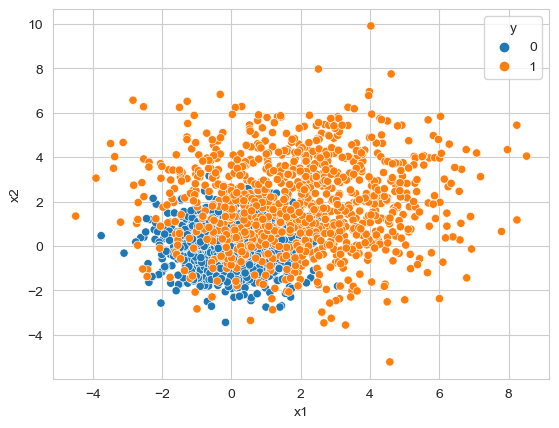

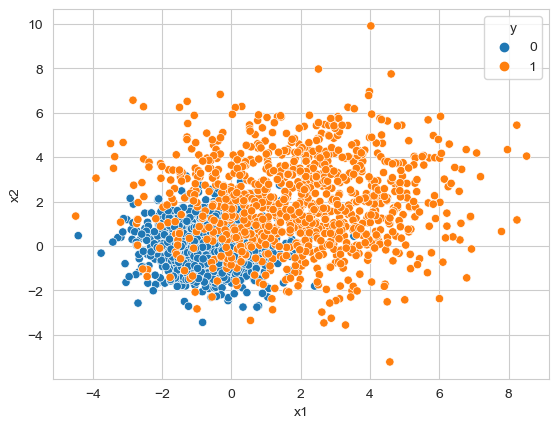

In [4]:
plt.figure()
sns.scatterplot(data=df, x='x1', y='x2', hue='y')
plt.show()
plt.figure()
sns.scatterplot(data=df_test, x='x1', y='x2', hue='y')
plt.show()


,insulation_resistance,capacitance_imbalance,cable_lot_assignment
0,3745.958629,1.603955,1
1,6446.631845,2.741794,0
2,2156.124547,0.567434,0
3,4015.926669,1.073053,1
4,3152.613060,1.833179,0
...,...,...,...
1995,3525.561452,1.212553,0
1996,3895.847627,1.162269,1
1997,4830.170196,0.636936,0
1998,3370.717020,1.316404,1


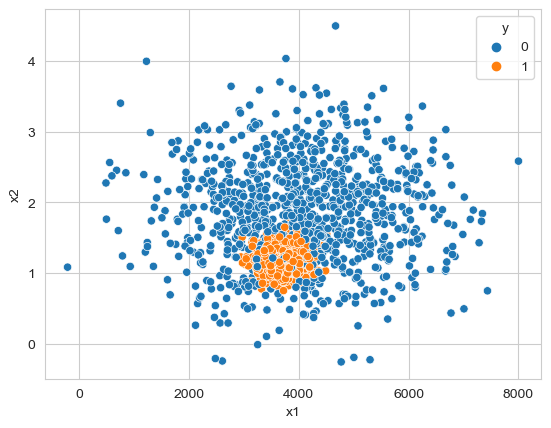

uniform
accuracy_train = 0.8605
accuracy_test = 0.857
accuracy_std = 0.0062

distance
accuracy_train = 1.0
accuracy_test = 0.9679
accuracy_std = 0.015

Прогресс
delta_accuracy_test = 0.1109


In [36]:
np.random.seed(42)

df = pd.read_csv('data/cable.csv')
display(df)
df = df.rename(columns = {'insulation_resistance': 'x1', 'capacitance_imbalance':'x2', 'cable_lot_assignment': 'y'})
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'y')
plt.show()
# Обучающий датафрейм
X_train = df.drop(columns = ['y'])
y_train =df['y']

score_train_list = []
score_test_list = []

for seed in range(100):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
    # Датафрейм для прогноза (тестовый), получается из обучающего параллельным переносом.
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Мало соседей, голоса равноправные
    model = KNeighborsClassifier(n_neighbors = 5, weights='uniform')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
# Набор accuracy на test'е на всех запусках
uniform = score_test_list
    
uni_accuracy_train = round(np.array(score_train_list).mean(), 4)
uni_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогноза
print('uniform')
print('accuracy_train =', uni_accuracy_train)
print('accuracy_test =', uni_accuracy_test)
print('accuracy_std =', round(np.array(uniform).std(), 4))
print('')

# Все заново для дургого голосования
score_train_list = []
score_test_list = []

for seed in range(100):
    
    s = np.random.normal(0, 2, 1)[0] 
    
    def shift(row):
        if row['y'] == 1:
            return row['x1'] + s
        else:
            return row['x1']
    
    df_test = df.copy()
    df_test['x1'] = df_test.apply(shift, axis=1)
                               
    X_test = df_test.drop(columns = ['y'])
    y_test =df_test['y']
    
    # Соседей много, голосование взвешенное
    model = KNeighborsClassifier(n_neighbors = 20, weights='distance')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    score_train = accuracy_score(y_train, y_train_pred)
    score_test = accuracy_score(y_test, y_test_pred)

    score_train_list.append(score_train)
    score_test_list.append(score_test)
    
distance = score_test_list
    
dist_accuracy_train = round(np.array(score_train_list).mean(), 4)
dist_accuracy_test = round(np.array(score_test_list).mean(), 4)

# Характеристики прогоноза
print('distance')
print('accuracy_train =', dist_accuracy_train)
print('accuracy_test =', dist_accuracy_test)
print('accuracy_std =', round(np.array(distance).std(), 4))
print('')

print('Прогресс')
print('delta_accuracy_test =', round(dist_accuracy_test - uni_accuracy_test, 4))

In [20]:
# Фиксируем сдвиг на одном уровне и смотрим на дисперсию от случайного seed'а
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Генерируем тестовые данные с ФИКСИРОВАННЫМ сдвигом
fixed_shifts = np.linspace(-200, 200, 10)

results = {'shift': [], 'uniform_std': [], 'distance_std': [], 
           'uniform_mean': [], 'distance_mean': []}

for shift_val in fixed_shifts:
    X_test_shifted = X_train.copy()
    X_test_shifted.loc[y_train == 1, 'x1'] += shift_val
    
    print('shift_val =', shift_val)

    uniform_acc = []
    distance_acc = []

    # Здесь варьируем только случайный seed модели (если есть)
    for seed in range(25):
        # k=5 uniform
        model_u = KNeighborsClassifier(n_neighbors=5, weights='uniform')
        model_u.fit(X_train, y_train)
        uniform_acc.append(accuracy_score(y_train, model_u.predict(X_test_shifted)))

        # k=500 distance
        model_d = KNeighborsClassifier(n_neighbors=500, weights='distance')
        model_d.fit(X_train, y_train)  
        distance_acc.append(accuracy_score(y_train, model_d.predict(X_test_shifted)))

    results['shift'].append(shift_val)
    results['uniform_std'].append(np.std(uniform_acc))
    results['distance_std'].append(np.std(distance_acc))
    results['uniform_mean'].append(np.mean(uniform_acc))
    results['distance_mean'].append(np.mean(distance_acc))

import pandas as pd
pd.DataFrame(results).round(4)


shift_val = -200.0
shift_val = -155.55555555555554
shift_val = -111.11111111111111
shift_val = -66.66666666666669
shift_val = -22.22222222222223
shift_val = 22.22222222222223
shift_val = 66.66666666666663
shift_val = 111.11111111111109
shift_val = 155.55555555555554
shift_val = 200.0


,shift,uniform_std,distance_std,uniform_mean,distance_mean
0,-200.0000,0.0,0.0,0.8055,0.9385
1,-155.5556,0.0,0.0,0.8110,0.9495
2,-111.1111,0.0,0.0,0.8205,0.9535
3,-66.6667,0.0,0.0,0.8320,0.9575
4,-22.2222,0.0,0.0,0.8405,0.9680
5,22.2222,0.0,0.0,0.8365,0.9630
6,66.6667,0.0,0.0,0.8280,0.9575
7,111.1111,0.0,0.0,0.8080,0.9415
8,155.5556,0.0,0.0,0.7990,0.9320
9,200.0000,0.0,0.0,0.7870,0.9210
